In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np
import os
import cdsapi
import xarray as xr

In [ ]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        "product_type": ["reanalysis"],
        "variable": [
            "10m_u_component_of_wind",
            "10m_v_component_of_wind",
            "2m_dewpoint_temperature",
            "2m_temperature",
            "mean_sea_level_pressure",
            "mean_wave_direction",
            "mean_wave_period",
            "sea_surface_temperature",
            "significant_height_of_combined_wind_waves_and_swell",
            "surface_pressure",
            "total_precipitation"
        ],
        "year": ["2024"],
        "month": [
            "07"
        ],
        "day": [
            "01", "02", "03",
            "04", "05", "06",
            "07", "08", "09",
            "10", "11", "12",
            "13", "14", "15",
            "16", "17", "18",
            "19", "20", "21",
            "22", "23", "24",
            "25", "26", "27",
            "28", "29", "30",
            "31"
        ],
        "time": [
            "00:00"
        ],
        "data_format": "netcdf",
        "download_format": "unarchived"
    },
    'era5_weather2.nc'
)


2025-04-07 20:05:49,701 WARNING [2025-04-03T00:00:00] System is in degraded status due to issues on the underlying infrastructure. Please follow status [here](https://status.ecmwf.int/) or in our [forum](https://forum.ecmwf.int/t/data-stores-in-degraded-status/12472)
2025-04-07 20:05:49,702 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-04-07 20:05:49,703 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-04-07 20:05:50,749 INFO Request ID is 466d329a-63e5-464e-91ae-fee1828ed022
2025-04-07 20:05:51,075 INFO status has been updated to accepted
2025-04-07 20:06:13,742 INFO status has been updated to running
2025-04-07 20:22:18,660 INFO status has been updated to successful


27994d1833aac9de9b44751db52b39d9.zip:   0%|          | 0.00/8.28G [00:00<?, ?B/s]

ChunkedEncodingError: ('Connection broken: IncompleteRead(6676871552 bytes read, 2215630375 more expected)', IncompleteRead(6676871552 bytes read, 2215630375 more expected))

In [56]:
# Load ERA5 NetCDF
ds = xr.open_dataset('era5_weather1.nc', engine='netcdf4')

# Convert from Kelvin to Celsius
ds['t2m'] = ds['t2m'] - 273.15
ds['d2m'] = ds['d2m'] - 273.15

# Compute relative humidity (approx)
rh = 100 * (np.exp((17.625 * ds['d2m']) / (243.04 + ds['d2m'])) /
            np.exp((17.625 * ds['t2m']) / (243.04 + ds['t2m'])))
ds['humidity'] = rh

# Compute wind speed
wind_speed = (ds['u10'] ** 2 + ds['v10'] ** 2) ** 0.5
ds['wind_speed'] = wind_speed

# Convert to DataFrame
df_weather = ds[['t2m', 'humidity', 'wind_speed']].to_dataframe().reset_index()
df_weather['date'] = pd.to_datetime(df_weather['valid_time']).dt.date
df_weather = df_weather.rename(columns={'latitude': 'lat', 'longitude': 'lon'})
ds


<xarray.Dataset> Size: 16MB
Dimensions:     (valid_time: 366, latitude: 41, longitude: 45)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01 ... 2024-12-31
  * latitude    (latitude) float64 328B 42.0 41.75 41.5 ... 32.5 32.25 32.0
  * longitude   (longitude) float64 360B -125.0 -124.8 -124.5 ... -114.2 -114.0
    expver      (valid_time) <U4 6kB '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    t2m         (valid_time, latitude, longitude) float32 3MB 11.66 ... 23.47
    d2m         (valid_time, latitude, longitude) float32 3MB 8.068 ... 1.546
    u10         (valid_time, latitude, longitude) float32 3MB -1.133 ... 0.9535
    v10         (valid_time, latitude, longitude) float32 3MB -1.258 ... -2.566
    humidity    (valid_time, latitude, longitude) float32 3MB 78.61 ... 23.68
    wind_speed  (valid_time, latitude, longitude) float32 3MB 1.693 ... 2.737
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-04-07T11:52 GRIB to CDM+CF via cfgrib-0.9.1...

In [9]:
# iterate through later
df = pd.read_csv(r"datasets\FIRMS\MODIS\fire_archive_M-C61_599044.csv")
df.head(5)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,38.5422,-78.3047,304.8,2.8,1.6,2000-11-01,250,Terra,MODIS,23,6.03,280.9,40.3,N,0
1,38.5451,-78.3107,309.9,2.8,1.6,2000-11-01,250,Terra,MODIS,79,6.03,280.7,58.8,N,0
2,38.5563,-78.3084,309.4,2.8,1.6,2000-11-01,250,Terra,MODIS,70,6.03,280.4,54.5,N,0
3,38.5586,-78.3170,302.3,2.8,1.6,2000-11-01,250,Terra,MODIS,45,6.03,279.8,36.0,N,0
4,31.3393,-89.9124,304.9,1.0,1.0,2000-11-01,427,Terra,MODIS,62,6.03,287.5,8.5,N,0


In [42]:
df['acq_time'] = df['acq_time'].astype(str).str.zfill(4)
df['datetime'] = pd.to_datetime(df['acq_date'] + ' ' + df['acq_time'], format='%Y-%m-%d %H%M')
df[['date', 'acq_time']].head(5)

,date,acq_time
0,2000-11-01,0250
1,2000-11-01,0250
2,2000-11-01,0250
3,2000-11-01,0250
4,2000-11-01,0427


In [24]:
df['date'] = pd.to_datetime(df['acq_date']).dt.date
df['lat'] = (df['latitude'] // 0.25) * 0.25
df['lon'] = (df['longitude'] // 0.25) * 0.25
df.head(5)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,date,lat,lon,fire_label
0,38.5422,-78.3047,304.8,2.8,1.6,2000-11-01,0250,Terra,MODIS,23,6.03,280.9,40.3,N,0,2000-11-01,38.50,-78.5,1
1,38.5451,-78.3107,309.9,2.8,1.6,2000-11-01,0250,Terra,MODIS,79,6.03,280.7,58.8,N,0,2000-11-01,38.50,-78.5,1
2,38.5563,-78.3084,309.4,2.8,1.6,2000-11-01,0250,Terra,MODIS,70,6.03,280.4,54.5,N,0,2000-11-01,38.50,-78.5,1
3,38.5586,-78.3170,302.3,2.8,1.6,2000-11-01,0250,Terra,MODIS,45,6.03,279.8,36.0,N,0,2000-11-01,38.50,-78.5,1
4,31.3393,-89.9124,304.9,1.0,1.0,2000-11-01,0427,Terra,MODIS,62,6.03,287.5,8.5,N,0,2000-11-01,31.25,-90.0,1


In [ ]:
# Mark fire cells
df['fire_label'] = 1
fire_cells = df[['lat', 'lon', 'date', 'fire_label']].drop_duplicates()

# Merge with weather
merged = df_weather.merge(fire_cells, on=['lat', 'lon', 'date'], how='inner')
merged['fire_label'] = merged['fire_label'].fillna(0)  # No fire = 0


In [34]:
merged.head(5)

,valid_time,lat,lon,t2m,humidity,wind_speed,number,expver,date,fire_label
0,2024-07-01,39.75,-122.00,37.074371,16.362822,1.906948,0,0001,2024-07-01,1
1,2024-07-01,39.50,-119.75,28.109528,18.164333,3.760430,0,0001,2024-07-01,1
2,2024-07-01,38.00,-120.00,27.328278,24.831619,3.058893,0,0001,2024-07-01,1
3,2024-07-01,37.75,-121.50,31.439606,30.164703,3.836728,0,0001,2024-07-01,1
4,2024-07-01,36.75,-119.25,32.918121,20.020229,2.399804,0,0001,2024-07-01,1


In [43]:
fires_daily = df.groupby(df['datetime'].dt.date).agg({
    'brightness': 'mean',
    'bright_t31': 'mean',
    'frp': 'mean',
    'latitude': 'count'
}).rename(columns={'latitude': 'fire_count'})

fires_daily.head(5)

,brightness,bright_t31,frp,fire_count
datetime,,,,
2000-11-01,316.330000,291.493077,21.699231,260
2000-11-02,313.003245,286.321239,29.215339,339
2000-11-03,315.840698,288.073643,28.141860,258
2000-11-04,312.785246,281.165574,23.560656,61
2000-11-05,316.954545,287.136364,30.765909,44


In [44]:
fires_daily['label'] = (fires_daily['fire_count'] > 0).astype(int)
fires_daily['label'].head(5)

datetime
2000-11-01    1
2000-11-02    1
2000-11-03    1
2000-11-04    1
2000-11-05    1
Name: label, dtype: int64

In [45]:
features = fires_daily[['brightness', 'bright_t31', 'frp']].fillna(0)
labels = fires_daily['label'].values

In [46]:
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

def seq(data, labels, window=7):
    x,y=[],[]
    for i in range(len(data)-window):
        x.append(data[i:i+window])
        y.append(labels[i+window])
    return np.array(x), np.array(y)

x, y = seq(features_scaled, labels)

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

model = Sequential([
    LSTM(64, input_shape=(x.shape[1], x.shape[2])),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, batch_size=16, validation_data=(x_test, y_test))

Epoch 1/5


c:\Users\olive\cs5131proj\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 1.0000 - loss: 0.1159 - val_accuracy: 1.0000 - val_loss: 5.8820e-05
Epoch 2/5
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 4.8486e-05 - val_accuracy: 1.0000 - val_loss: 2.9481e-05
Epoch 3/5
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 2.6202e-05 - val_accuracy: 1.0000 - val_loss: 1.9086e-05
Epoch 4/5
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 1.7514e-05 - val_accuracy: 1.0000 - val_loss: 1.3560e-05
Epoch 5/5
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 1.2623e-05 - val_accuracy: 1.0000 - val_loss: 1.0079e-05


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1759

    accuracy                           1.00      1759
   macro avg       1.00      1.00      1.00      1759
weighted avg       1.00      1.00      1.00      1759



c:\Users\olive\cs5131proj\venv\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


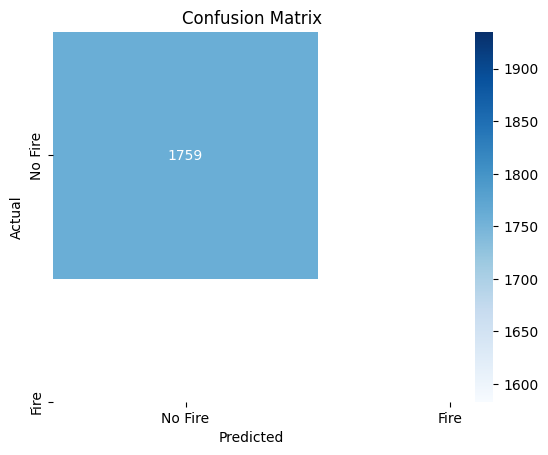

In [48]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_prob = model.predict(x_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Fire", "Fire"], yticklabels=["No Fire", "Fire"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [18]:
fires_daily['label'].value_counts()

label
1    8798
Name: count, dtype: int64